In [4]:
import pandas as pd

startup_list = pd.read_csv("datasets/Startup-Final list.csv")



In [5]:
startup_list["Date of foundation"] = pd.to_datetime(
    startup_list["Date of foundation"].astype(str).str.replace(".", "/", regex=False).str.strip(),
    format="%d/%m/%Y",
    errors="coerce"
)


startup_list["Startup Age (Years)"] = (
    (pd.Timestamp.today() - pd.to_datetime(startup_list["Date of foundation"], errors="coerce"))
    .dt.days / 365.25
).round(1)

In [6]:
import numpy as np
import plotly.express as px

max_age = startup_list["Startup Age (Years)"].max()
upper_bound = int(np.ceil(max_age / 5.0) * 5)

bins = list(range(0, upper_bound + 5, 5))
labels = [f"{i}-{i+4.9}" for i in bins[:-1]]

startup_list["Startup Age Bucket"] = pd.cut(
    startup_list["Startup Age (Years)"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

age_bucket_counts = (
    startup_list["Startup Age Bucket"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_bucket_counts.columns = ["Startup Age Bucket", "Count"]

fig = px.bar(
    age_bucket_counts,
    x="Startup Age Bucket",
    y="Count",
    color="Count",
    title="Startup Count by Age Bucket (5-Year Intervals)",
    color_continuous_scale=["#6B8E23", "#9ACD32", "#C5D86D", "#E9D66B", "#F4E285"]
)

fig.show()

In [7]:
import plotly.express as px

stage_counts = (
    startup_list["What stage of development is your solution currently at?"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)

stage_counts.columns = ["Stage", "Count"]

fig = px.treemap(
    stage_counts,
    path=["Stage"],
    values="Count",
    title="Startup Count by Development Stage",
    color="Count",
    color_continuous_scale=["#6B8E23", "#9ACD32", "#C5D86D", "#E9D66B", "#F4E285"]
)

fig.show()


In [8]:
startup_list["Website (eng)"]

0                         https://heft.systems/
1                         https://raymetra.pro/
2                           https://yharvest.io
3                     http://artaxe-studio.com/
4                        https://feodal.online/
5                           https://howcow.tech
6                         https://innoneers.com
7                           https://agronix.ua/
8                             https://valvix.ai
9                  https://profeed.systems/mix/
10    https://www.linkedin.com/company/safis-ai
11                    https://www.agrico.com.ua
12                         https://b2beings.com
13                        https://gis-point.com
14                     https://almexoft.com.ua/
15                https://www.siroccoenergy.com
Name: Website (eng), dtype: object

In [9]:
activity_category_map = {
    "https://heft.systems/": "Livestock / Dairy Tech",
    "https://raymetra.pro/": "Ag Storage / Inventory Monitoring",
    "https://yharvest.io": "Precision Agriculture / Field Intelligence",
    "http://artaxe-studio.com/": "Ag-Adjacent Enabling Tech",
    "https://feodal.online/": "Farm Operations / Land Management",
    "https://howcow.tech": "Livestock / Dairy Tech",
    "https://innoneers.com": "Ag-Adjacent Enabling Tech",
    "https://agronix.ua/": "Ag Drones / Ag Equipment",
    "https://valvix.ai": "Greenhouse / Controlled Environment Ag",
    "https://profeed.systems/mix/": "Livestock / Dairy Tech",
    "https://www.linkedin.com/company/safis-ai": "Precision Agriculture / Field Intelligence",
    "https://www.agrico.com.ua": "Seeds / Crop Genetics / Crop Production",
    "https://b2beings.com": "Ag-Adjacent Enabling Tech",
    "https://gis-point.com": "Agri GIS / Geospatial",
    "https://almexoft.com.ua/": "Ag-Adjacent Enabling Tech",
    "https://www.siroccoenergy.com": "Climate / Clean Energy"
}

startup_list["Activity Category"] = startup_list["Website (eng)"].map(activity_category_map)

In [10]:
activity_category_counts = (
    startup_list["Activity Category"]
    .dropna()
    .value_counts()
    .reset_index()
)

activity_category_counts.columns = ["Activity Category", "Count"]

fig = px.bar(
    activity_category_counts,
    x="Count",
    y="Activity Category",
    orientation="h",
    color="Count",
    title="Startup Count by Activity Category",
    color_continuous_scale=["#6B8E23", "#9ACD32", "#C5D86D", "#E9D66B", "#F4E285"]
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})

fig.show()

In [11]:
import numpy as np

startup_list["Number of employees"] = pd.to_numeric(
    startup_list["Number of employees"],
    errors="coerce"
)

max_employees = startup_list["Number of employees"].max()
upper_bound = int(np.ceil(max_employees / 10.0) * 10)

bins = list(range(0, upper_bound + 10, 10))
labels = [f"{i}-{i+9}" for i in bins[:-1]]

startup_list["Employee Bucket"] = pd.cut(
    startup_list["Number of employees"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

employee_bucket_counts = (
    startup_list["Employee Bucket"]
    .value_counts()
    .sort_index()
    .reset_index()
)

employee_bucket_counts.columns = ["Employee Bucket", "Count"]


employee_bucket_counts["Bucket Start"] = employee_bucket_counts["Employee Bucket"].astype(str).str.split("-").str[0].astype(int)
employee_bucket_counts = employee_bucket_counts.sort_values("Bucket Start", ascending=False)

fig = px.bar(
    employee_bucket_counts,
    x="Count",
    y="Employee Bucket",
    orientation="h",
    color="Count",
    title="Startup Count by Employee Bucket (10-Employee Intervals)",
    color_continuous_scale=["#6B8E23", "#9ACD32", "#C5D86D", "#E9D66B", "#F4E285"]
)

fig.show()



In [12]:
pd.set_option("display.max_colwidth", None)

startup_list[
    "Please describe the concrete outcomes you expect from participating in the Program (e.g., partnerships signed, pilot launches, investment raised, export contracts, etc.)."
]

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [13]:
pd.set_option("display.max_colwidth", None)

startup_list[
    "What are the key challenges your company faces when scaling internationally (regulatory, certification, partnerships, financing, localization, etc.)?"
]




0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

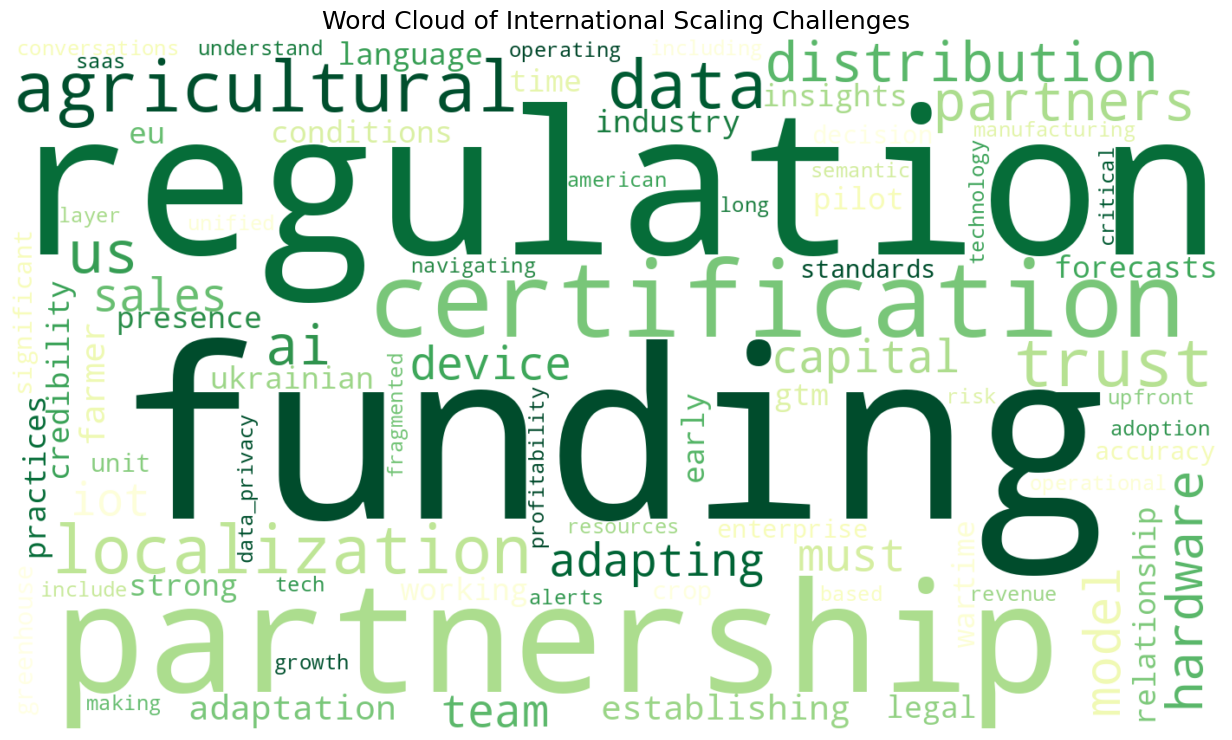

In [16]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

col = "What are the key challenges your company faces when scaling internationally (regulatory, certification, partnerships, financing, localization, etc.)?"

text = " ".join(
    startup_list[col]
    .dropna()
    .astype(str)
    .tolist()
)

custom_stopwords = set(STOPWORDS).union({
    "company", "scaling", "internationally", "international", "markets", "market",
    "new", "requires", "require", "challenge", "challenges", "key", "faces", "face",
    "etc", "also", "across", "different", "local", "global", "support", "building",
    "entering", "entry", "scale", "startup", "solution", "product", "platform",
    "customers", "customer", "countries", "country", "regions", "region", "ukraine"
})

# Normalize similar expressions
replacements = {
    r"\bregulatory compliance\b": "regulation",
    r"\bregulatory\b": "regulation",
    r"\bcompliance\b": "regulation",
    r"\bcertification\b": "certification",
    r"\bfcc\b": "certification",
    r"\bce\b": "certification",
    r"\bic\b": "certification",
    r"\bpartnerships\b": "partnership",
    r"\bdistributors\b": "distribution",
    r"\bdistributor\b": "distribution",
    r"\bdealers\b": "distribution",
    r"\bdealer\b": "distribution",
    r"\bfinancing\b": "funding",
    r"\binvestment\b": "funding",
    r"\binvestor\b": "funding",
    r"\blocalization\b": "localization",
    r"\blocalisation\b": "localization",
    r"\blocalized\b": "localization",
    r"\blocalisation\b": "localization",
    r"\btrust[- ]building\b": "trust",
    r"\bbrand recognition\b": "trust",
    r"\bmarket education\b": "adoption",
    r"\bpilot partnerships\b": "pilot",
    r"\bpilot programs\b": "pilot",
    r"\bpilots\b": "pilot",
    r"\bgo[- ]to[- ]market\b": "gtm",
    r"\bdata privacy\b": "data_privacy",
}

clean_text = text.lower()
for pattern, replacement in replacements.items():
    clean_text = re.sub(pattern, replacement, clean_text)

wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="YlGn",
    max_words=80,
    collocations=False
).generate(clean_text)

plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of International Scaling Challenges", fontsize=18)
plt.show()

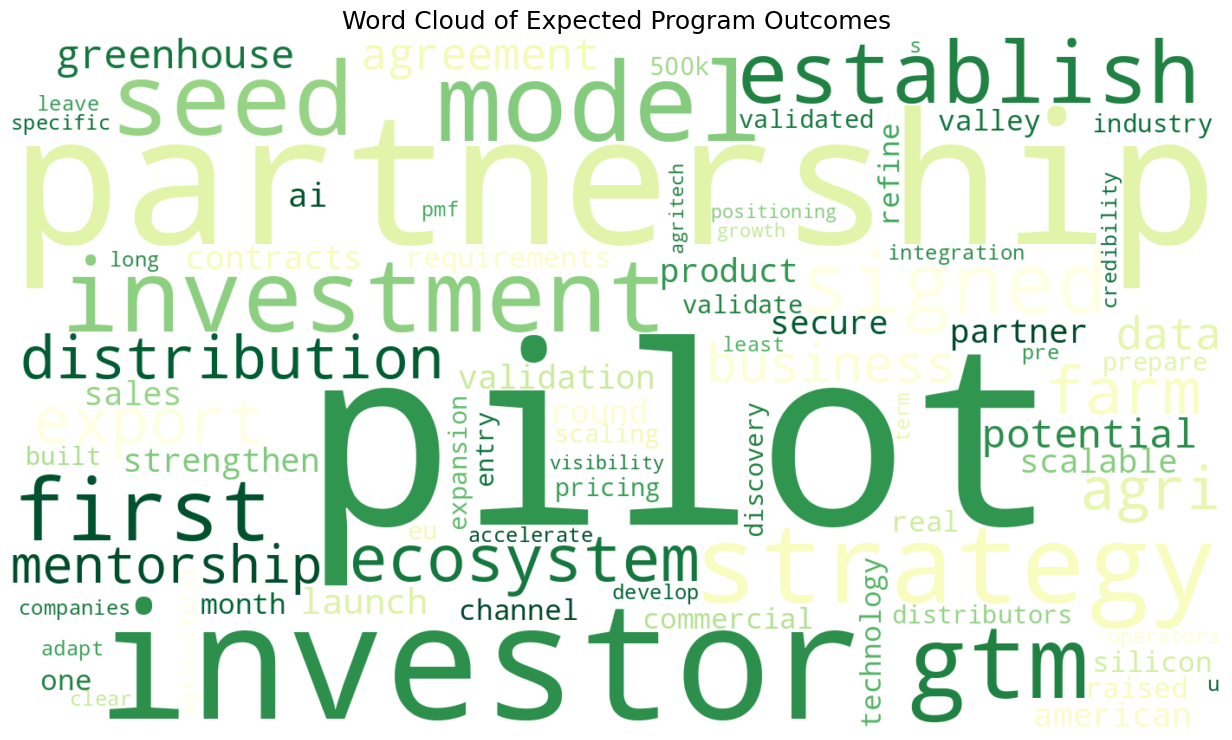

In [14]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter
import re

col = "Please describe the concrete outcomes you expect from participating in the Program (e.g., partnerships signed, pilot launches, investment raised, export contracts, etc.)."

text = " ".join(
    startup_list[col]
    .dropna()
    .astype(str)
    .tolist()
)

custom_stopwords = set(STOPWORDS).union({
    "program", "participating", "participation", "through", "expect", "expects", "expected",
    "goal", "goals", "outcomes", "concrete", "participate", "completion", "help", "support",
    "company", "startup", "solution", "market", "markets", "international", "us", "u.s",
    "new", "based", "within", "also", "will", "can", "aim", "aims", "want", "several",
    "ready", "readiness", "global", "participating", "berkeley"
})

# Optional normalization to merge similar ideas
replacements = {
    r"\bpilot projects?\b": "pilot",
    r"\bpilot launches?\b": "pilot",
    r"\bpilot deployments?\b": "pilot",
    r"\bpartnerships?\b": "partnership",
    r"\binvestor relationships?\b": "investor",
    r"\binvestor connections?\b": "investor",
    r"\binvestments?\b": "investment",
    r"\bgo[- ]to[- ]market\b": "gtm",
    r"\bproduct[- ]market fit\b": "pmf",
    r"\bcustomer discovery\b": "discovery",
    r"\bdistribution agreements?\b": "distribution",
    r"\bdealer agreements?\b": "distribution",
    r"\bexport contracts?\b": "export",
    r"\bcommercial agreements?\b": "commercial",
    r"\bstrategic partnerships?\b": "partnership",
}

clean_text = text.lower()
for pattern, replacement in replacements.items():
    clean_text = re.sub(pattern, replacement, clean_text)

wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="YlGn",   # agro-style greens/yellows
    max_words=80,
    collocations=False
).generate(clean_text)

plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Expected Program Outcomes", fontsize=18)
plt.show()

In [15]:
startup_list

,№,Company name,Type of the registered entity,Website (eng),EDRPOU code (Ukrainian state registry legal entity identifier),Date of foundation,Number of employees,Please indicate the percentage of gender distribution in сompany management,What is the type of your company:,Please select the AgriTech vertical(s) in which your company operates:,...,What geographic markets are you currently operating in?,"Has your company participated in international exhibitions, pitching competitions, demo days, or acceleration programs?",Please indicate the names of the events or programs.,What is your current funding status?,"What are the key challenges your company faces when scaling internationally (regulatory, certification, partnerships, financing, localization, etc.)?","Please describe the concrete outcomes you expect from participating in the Program (e.g., partnerships signed, pilot launches, investment raised, export contracts, etc.).",Startup Age (Years),Startup Age Bucket,Activity Category,Employee Bucket
0,1,HEFT,LLC Heft/ ТОВ Хефт,https://heft.systems/,45435842,NaT,7,70/30,Product-Service,"Smart farming / IoT solutions, Farm management software, Agri data analytics / AI solutions, Agri-biotech",...,"We are currently operating primarily in Ukraine, where we collaborate with dairy farms and industry partners through our existing PROFEED network.\n\nWe are also expanding internationally and already have pilot collaborations and customer interest in several European countries, including Romania, as well as connections with farms and industry partners in the United States and the EU.\n\nOur strategy is to scale first across Europe and North America, where dairy farms actively adopt precision livestock technologies.",True,"YEP Accelerator (Ukraine)\nSeeds of Bravery Incubator (EU program)\nNordeep 2025\nWorld Dairy Expo (USA)\nViva Technology (France)\nIT Arena Lviv Startup Competition – 2nd Place\nCES 2026 (Las Vegas, USA)\nSelectUSA Investment Summit (USA) 2026",Bootstrapped,"The main challenges in scaling internationally include building strong local partnerships with distributors and industry consultants, adapting the product to different market conditions, and expanding sales and support teams in new regions.\n\nAdditionally, hardware certification and logistics for IoT devices across different regulatory environments require time and resources.\n\nAccess to growth financing is also critical to accelerate manufacturing, localization, and market entry in the EU and North America.","We expect to establish partnerships with distributors and industry advisors in the US and EU, launch several pilot projects with dairy farms, and validate our solution in new markets.\n\nAdditionally, we aim to strengthen investor connections, secure strategic partnerships, and prepare for scaling international sales and manufacturing.",NaN,NaN,Livestock / Dairy Tech,0-9
1,2,Raymetra,Limited Liability Company (LLC / TOV),https://raymetra.pro/,46039903,NaT,6,90m/10w,Product-Service,Agri data analytics / AI solutions,...,"The company currently operates in Ukraine, focusing primarily on the agriculture and bulk storage sector, including grain elevators, warehouses, and processing facilities. The solution is designed to be scalable and can be deployed in other international markets in the future.",False,-,Bootstrapped,Our company has not yet scaled beyond Ukraine,Understanding the needs of global markets and how interesting our offer can be?,NaN,NaN,Ag Storage / Inventory Monitoring,0-9
2,3,Y-Harvest,LLC,https://yharvest.io,45750143,NaT,3,30/70,Start-up,"Smart farming / IoT solutions, Precision agriculture, Agri data analytics / AI solutions, Climate-smart / sustainable agriculture solutions",...,"Ukraine, starting pilots in Argentina",True,Tech Village 2025 (Moldova)\nScience and Buisness acceleration programm \nEIT Food 2025 \nUkraine agro summit 2025\nEIT founders2founders 2025\nAgrifood challange camp 2025,Bootstrapped,"partnerships, financing, localization

| Startup        | Website                                                                                | Activity Category                          | Notes                                                   |
| -------------- | -------------------------------------------------------------------------------------- | ------------------------------------------ | ------------------------------------------------------- |
| HEFT           | [https://heft.systems/](https://heft.systems/)                                         | Livestock / Dairy Tech                     | AI herd health and fertility monitoring                 |
| Raymetra       | [https://raymetra.pro/](https://raymetra.pro/)                                         | Ag Storage / Inventory Monitoring          | LiDAR and 3D monitoring for silos and warehouses        |
| YHarvest       | [https://yharvest.io](https://yharvest.io)                                             | Precision Agriculture / Field Intelligence | AI solutions for precision agriculture                  |
| artAXE         | [http://artaxe-studio.com/](http://artaxe-studio.com/)                                 | Ag-Adjacent Enabling Tech                  | IoT, firmware, hardware, and prototyping                |
| Feodal         | [https://feodal.online/](https://feodal.online/)                                       | Farm Operations / Land Management          | Platform for farmers, landowners, communities, demining |
| HowCow         | [https://howcow.tech](https://howcow.tech)                                             | Livestock / Dairy Tech                     | Likely cattle/dairy related; verify if needed           |
| Innoneers      | [https://innoneers.com](https://innoneers.com)                                         | Ag-Adjacent Enabling Tech                  | Engineering and intelligent software development        |
| Agronix        | [https://agronix.ua/](https://agronix.ua/)                                             | Ag Drones / Ag Equipment                   | DJI Agriculture drones, training, equipment services    |
| VALVIX.AI      | [https://valvix.ai](https://valvix.ai)                                                 | Greenhouse / Controlled Environment Ag     | Smart greenhouse automation                             |
| PROFEED Mix    | [https://profeed.systems/mix/](https://profeed.systems/mix/)                           | Livestock / Dairy Tech                     | Dairy farm software and feed management                 |
| SAFIS.AI       | [https://www.linkedin.com/company/safis-ai](https://www.linkedin.com/company/safis-ai) | Precision Agriculture / Field Intelligence | Soil and crop monitoring with IoT and AI                |
| Agrico Ukraine | [https://www.agrico.com.ua](https://www.agrico.com.ua)                                 | Seeds / Crop Genetics / Crop Production    | Seed and table potatoes                                 |
| b2beings       | [https://b2beings.com](https://b2beings.com)                                           | Ag-Adjacent Enabling Tech                  | B2B SaaS product development                            |
| GIS-Point      | [https://gis-point.com](https://gis-point.com)                                         | Agri GIS / Geospatial                      | GIS, IoT, and AI for agriculture                        |
| Almexoft       | [https://almexoft.com.ua/](https://almexoft.com.ua/)                                   | Ag-Adjacent Enabling Tech                  | Document management and workflow software               |
| Sirocco Energy | [https://www.siroccoenergy.com](https://www.siroccoenergy.com)                         | Climate / Clean Energy                     | Wind energy solutions                                   |
